In [1]:
import tensorflow as tf
from tensorflow.keras import models, layers
import matplotlib.pyplot as plt
import seaborn as sn
import numpy as np
import joblib
import pickle
from sklearn.metrics import confusion_matrix, classification_report

In [2]:
import warnings

warnings.filterwarnings('ignore')

In [3]:
import pandas as pd
data = 'D:/Ishita/IGDTUW (CSE)/Summer Internship 2024/Analytics (NER) Healthcare/Datasets/i2b2_2010_annotated.csv'
df = pd.read_csv(data, header=None)

In [4]:
df.columns = df.iloc[0]
df = df[1:]
df.head()

,Record,Word,POS,IOB,Tag
1,1,Admission,NN,B-NP,O
2,1,Date,NNP,I-NP,O
3,1,:,:,O,O
4,1,2012-10-31,JJ,B-NP,O
5,1,Discharge,NN,I-NP,O


In [5]:
import re
import spacy

import nltk
import string
#nltk.download('punkt')
nltk.download('stopwords')
from nltk.corpus import stopwords
STOP_WORDS = stopwords.words('english')
def clean_word(word):
    
    # remove non-alphanumeric characters and extra whitespaces
    word = re.sub(r'[^\w\s]','',word)
    word = re.sub(r'\s+',' ',word)
    
    # convert to lowercase
    word = word.lower()
    
    if word not in STOP_WORDS:
        return word
    
    return ''

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Admin\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [6]:
words = list(set(df["Word"].values))
words.append("ENDPAD")
num_words = len(words)
words_set = set(words)

# Clean and convert each word in df['Word']
df['Word'] = df['Word'].astype(str).apply(clean_word)

# Filter df to keep rows where 'Word' is in words_set
df = df[df['Word'].isin(words_set)]
words = list(set(df["Word"].values))
words.append("ENDPAD")
num_words = len(words)


tags = list(set(df["Tag"].values))
num_tags = len(tags)
word2idx = {w: i + 1 for i, w in enumerate(words)}
tag2idx = {t: i for i, t in enumerate(tags)}

In [7]:
print("Unique words in corpus:", df['Word'].nunique())
print("Unique tags in corpus:", df['Tag'].nunique())

Unique words in corpus: 8910
Unique tags in corpus: 7


In [8]:
print(df['Tag'].value_counts())

O              98143
I-problem      19581
B-problem      13110
I-treatment     8745
I-test          8737
B-treatment     8335
B-test          7188
Name: Tag, dtype: int64


In [9]:
import tqdm
def sentence_integrate(data):
  agg_func = lambda s: [(w, p, i, t) for w, p, i, t in zip(s["Word"].values.tolist(),
                                                           s["POS"].values.tolist(),
                                                           s["IOB"].values.tolist(),
                                                           s["Tag"].values.tolist())]
  return df.groupby('Record').apply(agg_func).tolist()
  
sentences=sentence_integrate(data)
  
sentences[0]


[('admission', 'NNP', 'B-NP', 'O'),
 ('date', 'NNP', 'I-NP', 'O'),
 ('discharge', 'NN', 'I-NP', 'O'),
 ('date', 'NNP', 'I-NP', 'O'),
 ('date', 'NNP', 'I-NP', 'O'),
 ('birth', 'NNP', 'B-NP', 'O'),
 ('service', 'NNP', 'I-NP', 'O'),
 ('cardiothoracic', 'JJ', 'B-NP', 'O'),
 ('allergies', 'NNS', 'I-NP', 'O'),
 ('patient', 'NN', 'B-NP', 'O'),
 ('recorded', 'VBD', 'B-VP', 'O'),
 ('known', 'NNP', 'I-NP', 'B-problem'),
 ('allergies', 'NNPS', 'I-NP', 'I-problem'),
 ('drugs', 'NNP', 'B-NP', 'B-treatment'),
 ('attending', 'NNP', 'I-NP', 'O'),
 ('chief', 'NNP', 'I-NP', 'O'),
 ('complaint', 'NNP', 'I-NP', 'O'),
 ('shortness', 'NN', 'B-NP', 'B-problem'),
 ('breath', 'NNP', 'B-NP', 'I-problem'),
 ('major', 'NNP', 'I-NP', 'O'),
 ('surgical', 'NNP', 'I-NP', 'O'),
 ('invasive', 'JJ', 'B-NP', 'O'),
 ('procedure', 'NN', 'I-NP', 'O'),
 ('coronary', 'JJ', 'B-NP', 'B-treatment'),
 ('artery', 'NNP', 'I-NP', 'I-treatment'),
 ('bypass', 'NNP', 'I-NP', 'I-treatment'),
 ('graft', 'NNP', 'I-NP', 'I-treatment'),
 ('

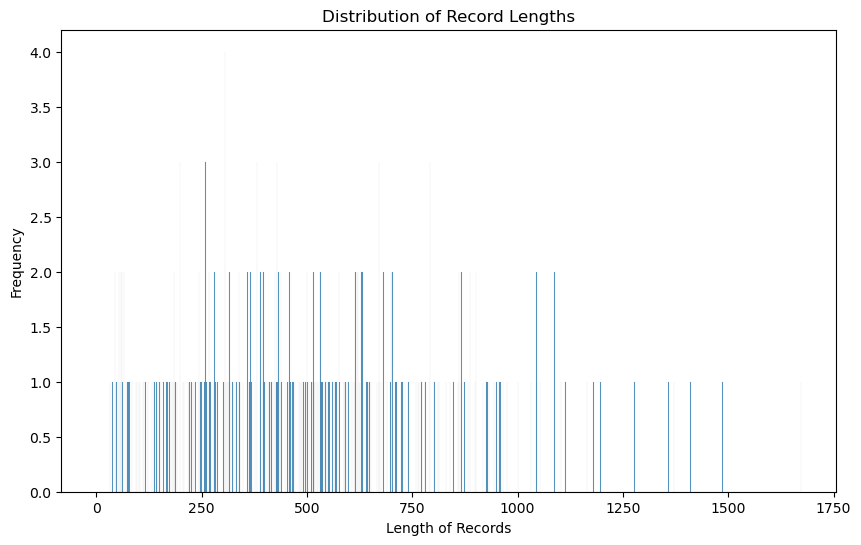

In [10]:
sentence_lengths = [len(sentence) for sentence in sentences]

# Plot the distribution
import seaborn as sns
plt.figure(figsize=(10, 6))
sns.histplot(sentence_lengths, bins=range(1, max(sentence_lengths) + 2), kde=False)
plt.title('Distribution of Record Lengths')
plt.xlabel('Length of Records')
plt.ylabel('Frequency')
plt.show()

In [11]:
print(sum(length > 1000 for length in sentence_lengths))

18


In [12]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

max_len = 1000

X = [[word2idx[w[0]] for w in s] for s in sentences]
X = pad_sequences(maxlen=max_len, sequences=X, padding="post", value=num_words-1)

y = [[tag2idx[w[3]] for w in s] for s in sentences]
y = pad_sequences(maxlen=max_len, sequences=y, padding="post", value=tag2idx["O"])

In [13]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)
X_val, X_test, y_val, y_test = train_test_split(X_test, y_test, test_size = 0.5, random_state = 42)

In [14]:
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.layers import Input, Embedding, Bidirectional, LSTM, Dense
from tensorflow.keras.optimizers.legacy import Adam

In [15]:
# Define the model architecture
INPUT_DIM = 8911
EMBEDDING_DIM = 64
MAX_LENGTH = 1000
NUM_CLASSES = 8

LSTM_UNITS = 64
DENSE_UNITS = 64
DROPOUT = 0.2
BATCH_SIZE = 32
EPOCHS = 50
model = tf.keras.models.Sequential([
    
    # Add a word embedding layer to learn the representations of words in the input text
    tf.keras.layers.Embedding(input_dim=INPUT_DIM, output_dim=EMBEDDING_DIM, input_length=MAX_LENGTH),
    
    # Add a Convolutional Neural Network (CNN) layer to capture local patterns in the text
    tf.keras.layers.Conv1D(filters=32, kernel_size=3, padding='same', activation='relu'),
    
    # Add a Bidirectional LSTM layer to capture contextual information from both directions
    tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(units=LSTM_UNITS, return_sequences=True)),
    
    # Add a TimeDistributed dense layer to apply a dense layer to each time step of the LSTM output
    tf.keras.layers.TimeDistributed(tf.keras.layers.Dense(units=DENSE_UNITS, activation='relu')),
    
    # Add a dropout layer to reduce overfitting
    tf.keras.layers.Dropout(rate=DROPOUT),
    
    # Add a dense layer with softmax activation to output the probabilities of each class
    tf.keras.layers.Dense(units=NUM_CLASSES, activation='softmax'),
])

# Compile the model
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding (Embedding)       (None, 1000, 64)          570304    
                                                                 
 conv1d (Conv1D)             (None, 1000, 32)          6176      
                                                                 
 bidirectional (Bidirectiona  (None, 1000, 128)        49664     
 l)                                                              
                                                                 
 time_distributed (TimeDistr  (None, 1000, 64)         8256      
 ibuted)                                                         
                                                                 
 dropout (Dropout)           (None, 1000, 64)          0         
                                                                 
 dense_1 (Dense)             (None, 1000, 8)           5

In [16]:
# Train the model
history = model.fit(
    X_train, 
    y_train, 
    epochs=EPOCHS, 
    validation_data=(X_val, y_val)
)

Epoch 1/50
9/9 [==============================] - 9s 604ms/step - loss: 1.9825 - accuracy: 0.7116 - val_loss: 1.6918 - val_accuracy: 0.8177
Epoch 2/50
9/9 [==============================] - 4s 475ms/step - loss: 1.2512 - accuracy: 0.8011 - val_loss: 0.8742 - val_accuracy: 0.8177
Epoch 3/50
9/9 [==============================] - 4s 498ms/step - loss: 0.8524 - accuracy: 0.8011 - val_loss: 0.7234 - val_accuracy: 0.8177
Epoch 4/50
9/9 [==============================] - 6s 637ms/step - loss: 0.7380 - accuracy: 0.8011 - val_loss: 0.6362 - val_accuracy: 0.8177
Epoch 5/50
9/9 [==============================] - 6s 667ms/step - loss: 0.6817 - accuracy: 0.8011 - val_loss: 0.6180 - val_accuracy: 0.8177
Epoch 6/50
9/9 [==============================] - 6s 697ms/step - loss: 0.6601 - accuracy: 0.8011 - val_loss: 0.6001 - val_accuracy: 0.8177
Epoch 7/50
9/9 [==============================] - 6s 673ms/step - loss: 0.6425 - accuracy: 0.8011 - val_loss: 0.5880 - val_accuracy: 0.8177
Epoch 8/50
9/9 [====

In [17]:
predictions = [model.predict(np.array([x])) for x in X_test]
predicted_labels = [np.argmax(pred[0], axis=-1) for pred in predictions]

# Flatten the test labels and predicted labels
y_test_flat = [label for sublist in y_test for label in sublist]
predicted_labels_flat = [label for sublist in predicted_labels for label in sublist]


1/1 [==============================] - 0s 80ms/step


In [18]:
# Print classification report
print(classification_report(y_test_flat, predicted_labels_flat))

              precision    recall  f1-score   support

           0       0.64      0.62      0.63       888
           1       0.97      0.98      0.97     27293
           2       0.73      0.71      0.72      1084
           3       0.74      0.71      0.72      1612
           4       0.69      0.64      0.66       791
           5       0.69      0.69      0.69       832
           6       0.65      0.70      0.67       500

    accuracy                           0.93     33000
   macro avg       0.73      0.72      0.72     33000
weighted avg       0.93      0.93      0.93     33000



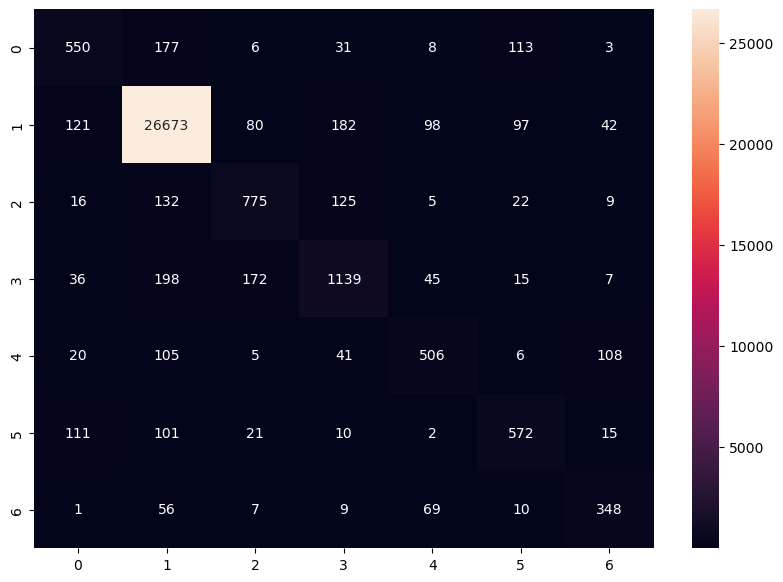

In [19]:
cm=tf.math.confusion_matrix(y_test_flat, predicted_labels_flat)
plt.figure(figsize=(10,7))
sn.heatmap(cm,annot=True,fmt='d')
plt.xlabel=('Predicted')
plt.ylabel=('Truth')